In [1]:
import pandas as pd
import numpy as np
import math, os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import seaborn as sns

train=pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
test=pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')

idList=test['id']
train.drop(columns=['id'], inplace=True)
target=train['health_condition']

<Axes: >

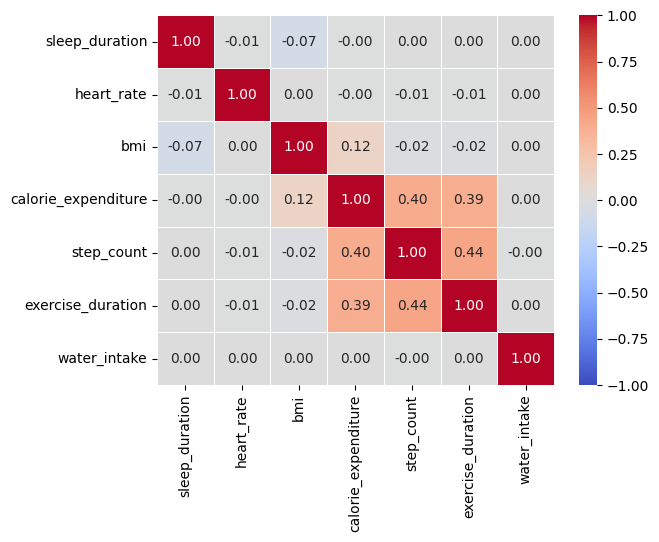

In [2]:
corrMat=train.corr(numeric_only=True)

sns.heatmap(corrMat, cmap='coolwarm', annot=True, vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)

In [3]:
idList.info()

<class 'pandas.core.series.Series'>
RangeIndex: 295753 entries, 0 to 295752
Series name: id
Non-Null Count   Dtype
--------------   -----
295753 non-null  int64
dtypes: int64(1)
memory usage: 2.3 MB


In [4]:
cols=['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level',\
     'smoking_alcohol', 'gender']

for i in cols:
    test[i]=test[i].astype('category')

In [5]:
cols=['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level',\
     'smoking_alcohol', 'gender']

train=train.drop(columns=['health_condition'])
for i in cols:
    train[i]=train[i].astype('category')

In [6]:
sample=pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv', header=0)
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                295753 non-null  int64 
 1   health_condition  295753 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.5+ MB


In [7]:
test.drop(columns=['id'], inplace=True)

In [8]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

x_train, x_test, y_train, y_test=train_test_split(train, target, test_size=0.2, stratify=target)
model=lgb.LGBMClassifier(boosting_type='gbdt', num_leaves=31, max_depth=-1,
    learning_rate=0.05,
    n_estimators=100,
    random_state=42)

model.fit(x_train, y_train)
y_pred=model.predict(x_test)
acc=accuracy_score(y_test, y_pred)
print(acc)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 13
[LightGBM] [Info] Start training from score -0.152364
[LightGBM] [Info] Start training from score -2.852889
[LightGBM] [Info] Start training from score -2.481150
0.9670260400817284


In [9]:
test_pred=model.predict(test)

In [10]:
ans=pd.DataFrame({'id': idList, 'health_condition': test_pred})
ans

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,at-risk
295751,985839,at-risk


In [11]:
ans.to_csv('/kaggle/working/output.csv', index=False)